In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pcntoolkit import (
    HBR,
    NormativeModel,
    NormData,
    SHASHbLikelihood,
    make_prior,
    BsplineBasisFunction,
)

sns.set_style("darkgrid")

In [2]:
from parsing import run_parsing_pipeline

df, dem_df = run_parsing_pipeline()

Updating repository in: data\PAM50-normalized-metrics


In [3]:
display(df.head())
df.columns

,Timestamp,SCT Version,Filename,Slice (I->S),VertLevel,DistancePMJ,MEAN(area),STD(area),MEAN(angle_AP),STD(angle_AP),...,researcher,pathology,notes,source_id,species,stenosis,dataset_name,MEAN(compression_ratio),sex_bin,dataset_id
561,2025-01-30 15:37:23,git-master-310834f50bfc9e3f9c68d696ada10a2223a...,sub-amu01/anat/sub-amu01_T2w_label-SC_seg.nii.gz,601,10,NaN,34.567890,0.0,1.487240,0.0,...,Virginie Callot,HC,NaN,NaN,homo sapiens,NaN,spine-generic_multi-subject,0.695988,0,0
562,2025-01-30 15:37:23,git-master-310834f50bfc9e3f9c68d696ada10a2223a...,sub-amu01/anat/sub-amu01_T2w_label-SC_seg.nii.gz,602,10,NaN,34.844010,0.0,1.442995,0.0,...,Virginie Callot,HC,NaN,NaN,homo sapiens,NaN,spine-generic_multi-subject,0.685281,0,0
563,2025-01-30 15:37:23,git-master-310834f50bfc9e3f9c68d696ada10a2223a...,sub-amu01/anat/sub-amu01_T2w_label-SC_seg.nii.gz,603,10,NaN,36.331712,0.0,1.399214,0.0,...,Virginie Callot,HC,NaN,NaN,homo sapiens,NaN,spine-generic_multi-subject,0.715369,0,0
564,2025-01-30 15:37:23,git-master-310834f50bfc9e3f9c68d696ada10a2223a...,sub-amu01/anat/sub-amu01_T2w_label-SC_seg.nii.gz,604,10,NaN,36.895389,0.0,1.355851,0.0,...,Virginie Callot,HC,NaN,NaN,homo sapiens,NaN,spine-generic_multi-subject,0.720625,0,0
565,2025-01-30 15:37:23,git-master-310834f50bfc9e3f9c68d696ada10a2223a...,sub-amu01/anat/sub-amu01_T2w_label-SC_seg.nii.gz,605,10,NaN,36.791714,0.0,1.312789,0.0,...,Virginie Callot,HC,NaN,NaN,homo sapiens,NaN,spine-generic_multi-subject,0.708008,0,0


Index(['Timestamp', 'SCT Version', 'Filename', 'Slice (I->S)', 'VertLevel',
       'DistancePMJ', 'MEAN(area)', 'STD(area)', 'MEAN(angle_AP)',
       'STD(angle_AP)', 'MEAN(angle_RL)', 'STD(angle_RL)', 'MEAN(diameter_AP)',
       'STD(diameter_AP)', 'MEAN(diameter_RL)', 'STD(diameter_RL)',
       'MEAN(eccentricity)', 'STD(eccentricity)', 'MEAN(orientation)',
       'STD(orientation)', 'MEAN(solidity)', 'STD(solidity)', 'SUM(length)',
       'participant_id', 'sex', 'age', 'height', 'weight', 'date_of_scan',
       'institution', 'manufacturer', 'manufacturers_model_name',
       'receive_coil_name', 'software_versions', 'researcher', 'pathology',
       'notes', 'source_id', 'species', 'stenosis', 'dataset_name',
       'MEAN(compression_ratio)', 'sex_bin', 'dataset_id'],
      dtype='object')

In [4]:
from config.metrics import METRICS

metric = METRICS[0]

df_model = df.copy()

required_cols = ["age", "sex_bin", "dataset_name", "Slice (I->S)", "participant_id"] + [metric]
df_model = df_model.dropna(subset=required_cols)

# types
df_model["age"] = df_model["age"].astype(int)
df_model["sex_bin"] = df_model["sex_bin"].astype(int)
df_model["dataset_id"] = df_model["dataset_id"].astype(int)
df_model["slice"] = df_model["Slice (I->S)"].astype(int)
df_model["subject_id"] = df_model["participant_id"]

In [5]:
norm_data = NormData.from_dataframe(
    name="first",
    dataframe=df_model,
    response_vars=[metric],
    covariates=["Slice (I->S)", "age",],
    batch_effects=["dataset_name", "sex_bin"],
    subject_ids="subject_id",
)

Process: 6956 - 2026-06-29 10:18:21 - Dataset "first" created.
    - 125040 observations
    - 251 unique subjects
    - 2 covariates
    - 1 response variables
    - 2 batch effects:
    	dataset_name (2)
	sex_bin (2)
    


In [6]:
train, test = norm_data.train_test_split()

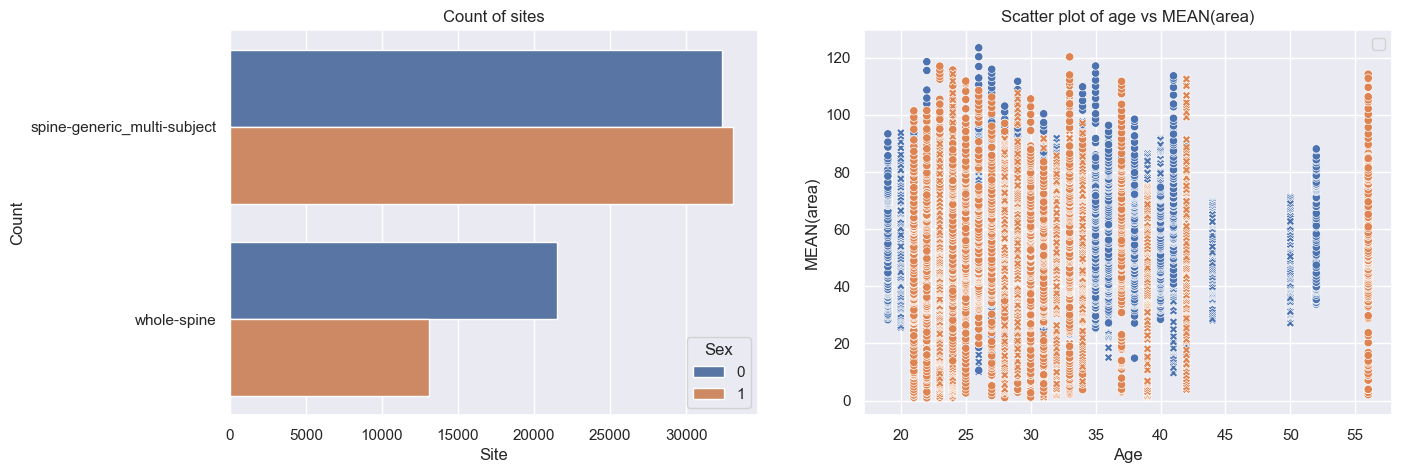

In [7]:
# Visualize the data
feature_to_plot = METRICS[0]
df = train.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, y=("batch_effects", "dataset_name"), hue=("batch_effects", "sex_bin"), ax=ax[0], orient="h")
ax[0].legend(title="Sex")
ax[0].set_title("Count of sites")
ax[0].set_xlabel("Site")
ax[0].set_ylabel("Count")


sns.scatterplot(
    data=df,
    x=("X", "age"),
    y=("Y", feature_to_plot),
    hue=("batch_effects", "dataset_name"),
    style=("batch_effects", "sex_bin"),
    ax=ax[1],
)
ax[1].legend([], [])
ax[1].set_title(f"Scatter plot of age vs {feature_to_plot}")
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)

plt.show()

In [11]:
# The SHASHb likelihood is a bit more flexible than the Normal likelihood, and takes four parameters, mu, sigma, epsilon, and delta.
# Mu and sigma fulfill the same role as in the Normal likelihood, namely the mean and standard deviation of the distribution.
# Epsilon and delta are parameters that control the skewness and kurtosis of the distribution.

# SHASHb model with fixed values for epsilon and delta

mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 5.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        sigma=make_prior(
            dist_name="Normal", dist_params=(0.0, 1.0), mapping="softplus", mapping_params=(0.0, 3.0),),
    ),
    basis_function=BsplineBasisFunction(basis_column=[0,1], nknots=6, degree=3),
)

sigma = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    mapping="softplus",
    basis_function=BsplineBasisFunction(basis_column=[0,1], nknots=5, degree=3),
    mapping_params=(0.0, 2.0),
)

epsilon = make_prior(
    # Epsilon is assumed to follow a normal distribution, with a mean of 0 and a standard deviation of 1.
    dist_name="Normal",
    dist_params=(0.0, 1.0),
)

delta = make_prior(
    # Delta is sampled from a normal distribution, with a mean of 1 and a standard deviation of 1, and then mapped to the positive real line using a softplus function.
    dist_name="Normal",
    dist_params=(1.0, 1.0),
    mapping="softplus",
    # We apply a softplus mapping to the delta parameter, to ensure that it is strictly positive.
    mapping_params=(
        0.0,  # Horizontal shift
        3.0,  # Scale for smoothness
        0.6,  # We need to provide a vertical shift as well, because the SHASH mapping goes a bit wild with low values for delta
    ),
)

shashb1_regression_model = HBR(
    name="spinal_cord_pcn",
    cores=8,
    progressbar=True,
    draws=1000,
    tune=500,
    chains=2,
    nuts_sampler="nutpie",
    likelihood=SHASHbLikelihood(mu, sigma, epsilon, delta),
)

In [12]:
model = NormativeModel(
    # The regression model to use for the normative model.
    template_regression_model=shashb1_regression_model,
    # Whether to save the model after fitting.
    savemodel=True,
    # Whether to evaluate the model after fitting.
    evaluate_model=True,
    # Whether to save the results after evaluation.
    saveresults=True,
    # Whether to save the plots after fitting.
    saveplots=False,
    # The directory to save the model, results, and plots.
    save_dir="resources/hbr_SHASH/save_dir2",
    # The scaler to use for the input data. Can be either one of "standardize", "minmax", "robminmax", "none"
    inscaler="standardize",
    # The scaler to use for the output data. Can be either one of "standardize", "minmax", "robminmax", "none"
    outscaler="standardize",
)

In [13]:
model.fit_predict(train, test)

Process: 6956 - 2026-06-29 10:20:29 - Fitting models on 1 response variables.
Process: 6956 - 2026-06-29 10:20:29 - Fitting model for MEAN(area).


C:\Users\leana\AppData\Roaming\Python\Python312\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,1,0.26,31
,1500,0,0.26,31


Process: 6956 - 2026-06-29 10:52:10 - Saving model to:
	resources/hbr_SHASH/save_dir2.
Process: 6956 - 2026-06-29 10:52:11 - Making predictions on 1 response variables.
Process: 6956 - 2026-06-29 10:52:11 - Computing z-scores for 1 response variables.
Process: 6956 - 2026-06-29 10:52:11 - Computing z-scores for MEAN(area).


Sampling: []


MemoryError: Unable to allocate 1.49 GiB for an array with shape (100032, 2000) and data type float64

In [14]:
train

<xarray.NormData> Size: 26MB
Dimensions:            (observations: 100032, response_vars: 1, covariates: 2,
                        batch_effect_dims: 2)
Coordinates:
  * observations       (observations) int64 800kB 93032 46415 ... 13871 76346
  * response_vars      (response_vars) <U10 40B 'MEAN(area)'
  * covariates         (covariates) <U12 96B 'Slice (I->S)' 'age'
  * batch_effect_dims  (batch_effect_dims) <U12 96B 'dataset_name' 'sex_bin'
Data variables:
    subject_ids        (observations) object 800kB 'sub-amuPA' ... 'sub-vallH...
    Y                  (observations, response_vars) float64 800kB -1.194 ......
    X                  (observations, covariates) float64 2MB -0.6469 ... -0....
    batch_effects      (observations, batch_effect_dims) <U27 22MB 'whole-spi...
    Z                  (observations, response_vars) float64 800kB 0.0 ... 0.0
Attributes:
    real_ids:                       True
    is_scaled:                      True
    name:                           first_train
    unique_batch_effects:           {np.str_('dataset_name'): ['spine-generic...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('Slice (I->S)'): {'min': 40.0, '...
    batch_effect_covariate_ranges:  {np.str_('dataset_name'): {'spine-generic...

In [15]:
test

<xarray.NormData> Size: 6MB
Dimensions:            (observations: 25008, response_vars: 1, covariates: 2,
                        batch_effect_dims: 2)
Coordinates:
  * observations       (observations) int64 200kB 88869 109308 ... 9600 96051
  * response_vars      (response_vars) <U10 40B 'MEAN(area)'
  * covariates         (covariates) <U12 96B 'Slice (I->S)' 'age'
  * batch_effect_dims  (batch_effect_dims) <U12 96B 'dataset_name' 'sex_bin'
Data variables:
    subject_ids        (observations) object 200kB 'sub-amuJD' ... 'sub-amuVC'
    Y                  (observations, response_vars) float64 200kB 70.74 ... ...
    X                  (observations, covariates) int64 400kB 891 33 ... 912 39
    batch_effects      (observations, batch_effect_dims) <U27 5MB 'whole-spin...
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           first_test
    unique_batch_effects:           {np.str_('dataset_name'): ['spine-generic...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('Slice (I->S)'): {'min': 40.0, '...
    batch_effect_covariate_ranges:  {np.str_('dataset_name'): {'spine-generic...

Process: 23900 - 2026-06-29 10:10:36 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 2 covariates
    - 1 response variables
    - 2 batch effects:
    	dataset_name (1)
	sex_bin (1)
    
Process: 23900 - 2026-06-29 10:10:36 - Computing centiles for 1 response variables.
Process: 23900 - 2026-06-29 10:10:36 - Computing centiles for MEAN(area).


Sampling: []
Sampling: []
Sampling: []


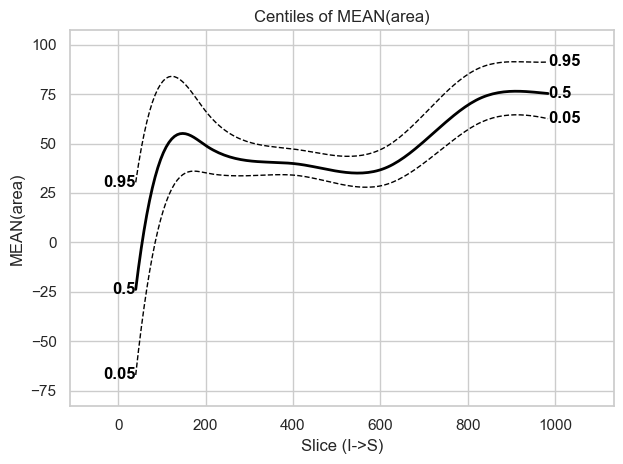

[<Figure size 640x480 with 1 Axes>]

In [12]:
from pcntoolkit import plot_centiles_advanced
plot_centiles_advanced(
    model,
    centiles=[0.05, 0.5, 0.95],  # Plot these centiles, the default is [0.05, 0.25, 0.5, 0.75, 0.95]
    show_other_data=True,  # scatter data not in those groups as smaller black circles
    harmonize_data=True,  # harmonize the scatterdata, this means that we 'remove' the batch effects from the data, by simulating what the data would have looked like if all data was from the same batch.
    # conditionals=[30]
)